In [22]:
# 读取 WayMo 的 tfrecord 文件所必须的安装包，只能在 Linux 上安装，建议使用 Python3.10 版本（别的版本装不上 waymo-open-dataset)
!pip install tensorflow=2.12.0
!pip install waymo-open-dataset-tf-2-12-0==1.6.7

Defaulting to user installation because normal site-packages is not writeable
ERROR: Invalid requirement: 'tensorflow=2.12.0'
Hint: = is not a valid operator. Did you mean == ?
Defaulting to user installation because normal site-packages is not writeable


In [24]:
import yaml
import pandas as pd
from tqdm import tqdm
from itertools import islice
import tensorflow as tf
from waymo_open_dataset.protos import scenario_pb2

def get_df_data(scenario, use_tqdm=False):
    df_list = []
    for track in tqdm(scenario.tracks, disable=not use_tqdm):
        for frame, state in enumerate(track.states):
            if state.valid:
                row = dict(
                    center_x=state.center_x,
                    center_y=state.center_y,
                    center_z=state.center_z,
                    length=state.length,
                    width=state.width,
                    height=state.height,
                    heading=state.heading,
                    velocity_x=state.velocity_x,
                    velocity_y=state.velocity_y,
                    f=frame,
                    id=track.id,
                    type=track.object_type,
                )
                df_list.append(row)
    df = pd.DataFrame(df_list)
    df['type'] = df['type'].map({0: 'UNSET', 1: 'VEHICLE', 2: 'PEDESTRIAN', 3: 'CYCLIST', 4: 'OTHER'})
    return df

filename = "../data/WayMo/Motion/training_20s.tfrecord-00874-of-01000"
scenario_idx = 2  # 选择这个数据集文件中的第 2 个场景

dataset = tf.data.TFRecordDataset(filename, compression_type='')
data = next(islice(dataset, scenario_idx, None), None)
scenario = scenario_pb2.Scenario()
scenario.ParseFromString(data.numpy())
print("Scenario ID:", scenario.scenario_id)
print("Number of tracks:", len(scenario.tracks))
print("Map features:", len(scenario.map_features))
df = get_df_data(scenario, use_tqdm=True)
df

Scenario ID: b506cca56fe43ba9
Number of tracks: 347
Map features: 279


100%|██████████| 347/347 [00:00<00:00, 6997.26it/s]


,center_x,center_y,center_z,length,width,height,heading,velocity_x,velocity_y,f,id,type
0,2217.511475,-2524.376465,-467.257765,0.764236,0.761600,1.630999,4.681386,-0.130615,-0.513916,42,6146,PEDESTRIAN
1,2217.485352,-2524.479248,-467.266260,0.793265,0.771323,1.641379,-1.742093,-0.429688,-0.151367,44,6146,PEDESTRIAN
2,2217.442383,-2524.494385,-467.256892,0.787042,0.766815,1.647027,3.366364,-0.429688,-0.151367,45,6146,PEDESTRIAN
3,2217.371582,-2524.589355,-467.269589,0.804773,0.768425,1.660969,3.089929,-0.708008,-0.949707,46,6146,PEDESTRIAN
4,2217.316406,-2524.629150,-467.260218,0.792658,0.767348,1.648304,-1.534146,-0.551758,-0.397949,47,6146,PEDESTRIAN
...,...,...,...,...,...,...,...,...,...,...,...,...
22008,2226.851003,-2486.111221,-467.193889,5.286000,2.332000,2.330000,1.109649,0.110324,0.221477,193,6614,VEHICLE
22009,2226.863656,-2486.086822,-467.193329,5.286000,2.332000,2.330000,1.109745,0.129018,0.258795,194,6614,VEHICLE
22010,2226.876807,-2486.059463,-467.193703,5.286000,2.332000,2.330000,1.109745,0.140996,0.289368,195,6614,VEHICLE
22011,2226.891852,-2486.028954,-467.195077,5.286000,2.332000,2.330000,1.109745,0.159084,0.325524,196,6614,VEHICLE


In [25]:
import json
from pathlib import Path
from google.protobuf.json_format import MessageToJson, MessageToDict

json_str = MessageToJson(scenario, including_default_value_fields=True)

filename_idx = Path(filename).name.removeprefix('training_20s.tfrecord-').removesuffix('-of-01000')
scenario_id = scenario.scenario_id
with open(f'scenario_{filename_idx}_{scenario_idx}_{scenario_id}.json', 'w') as f:
    f.write(json_str)

2173.521520996094 2271.46987121582 -2575.6144287109373 -2407.7539587402343


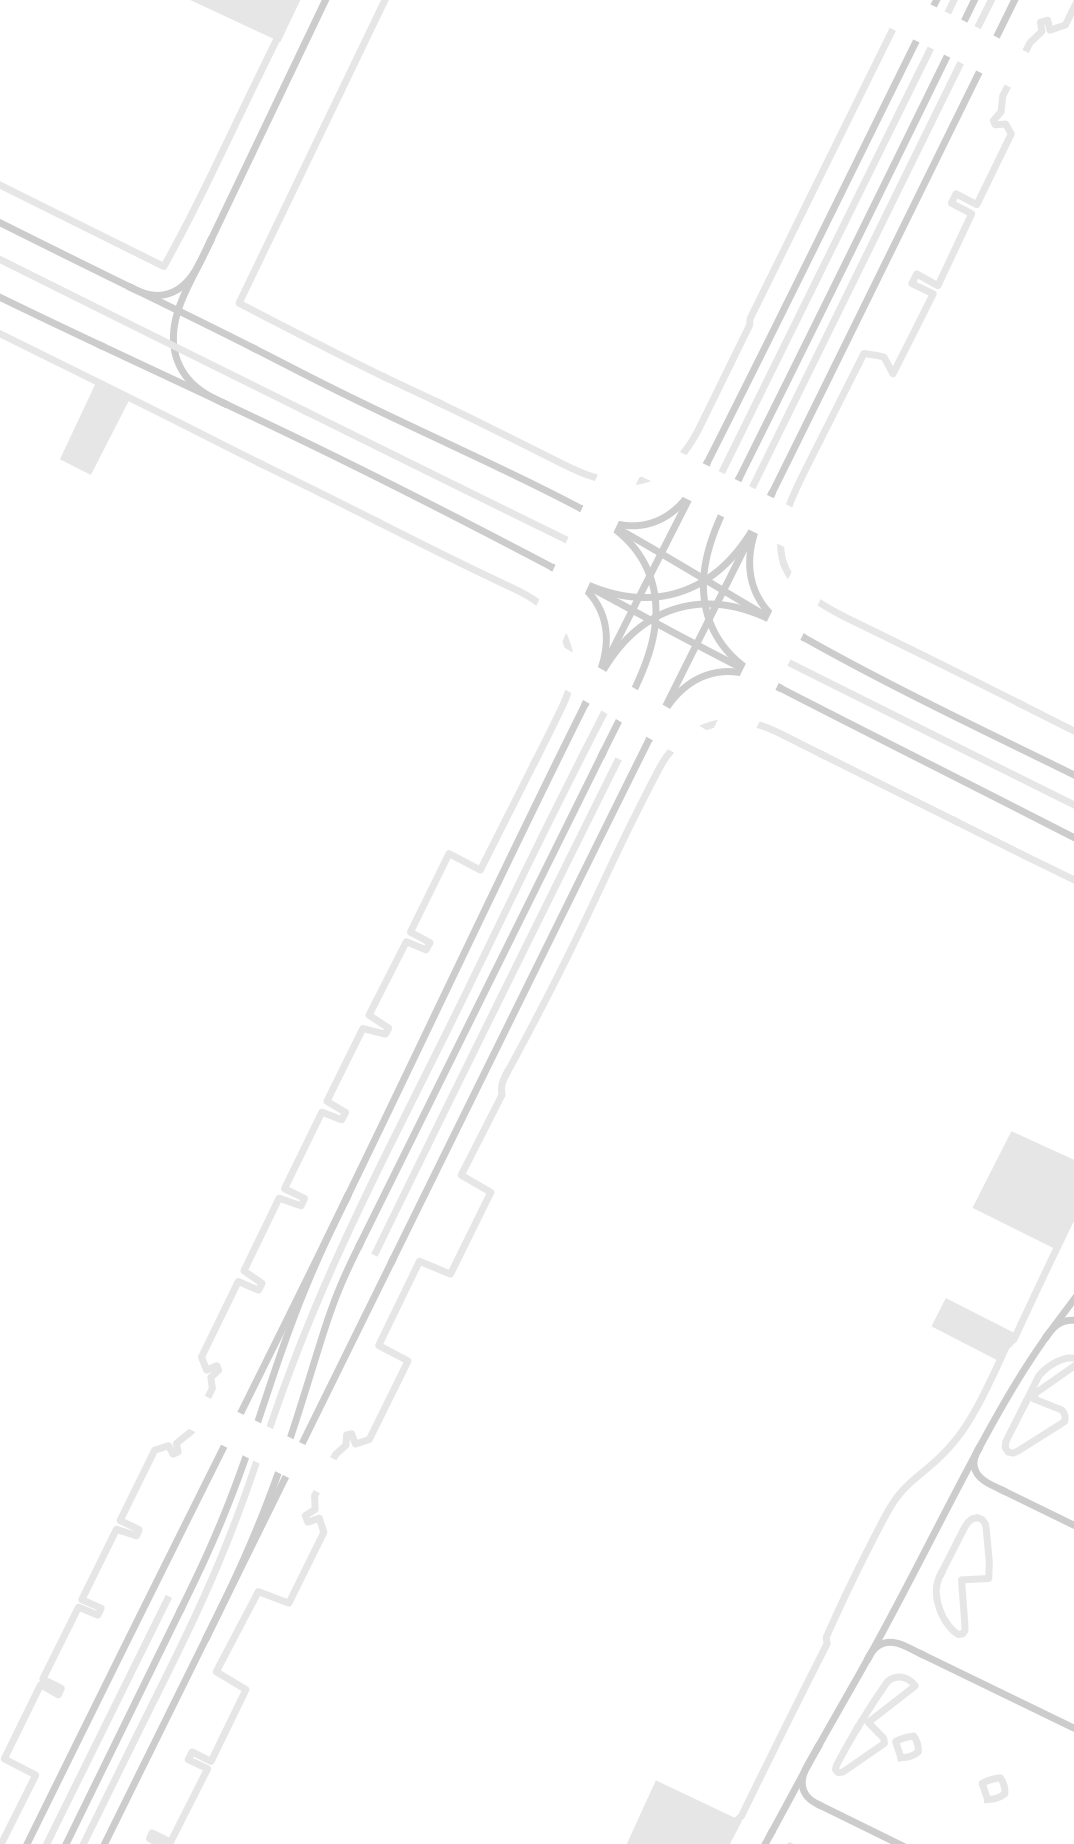

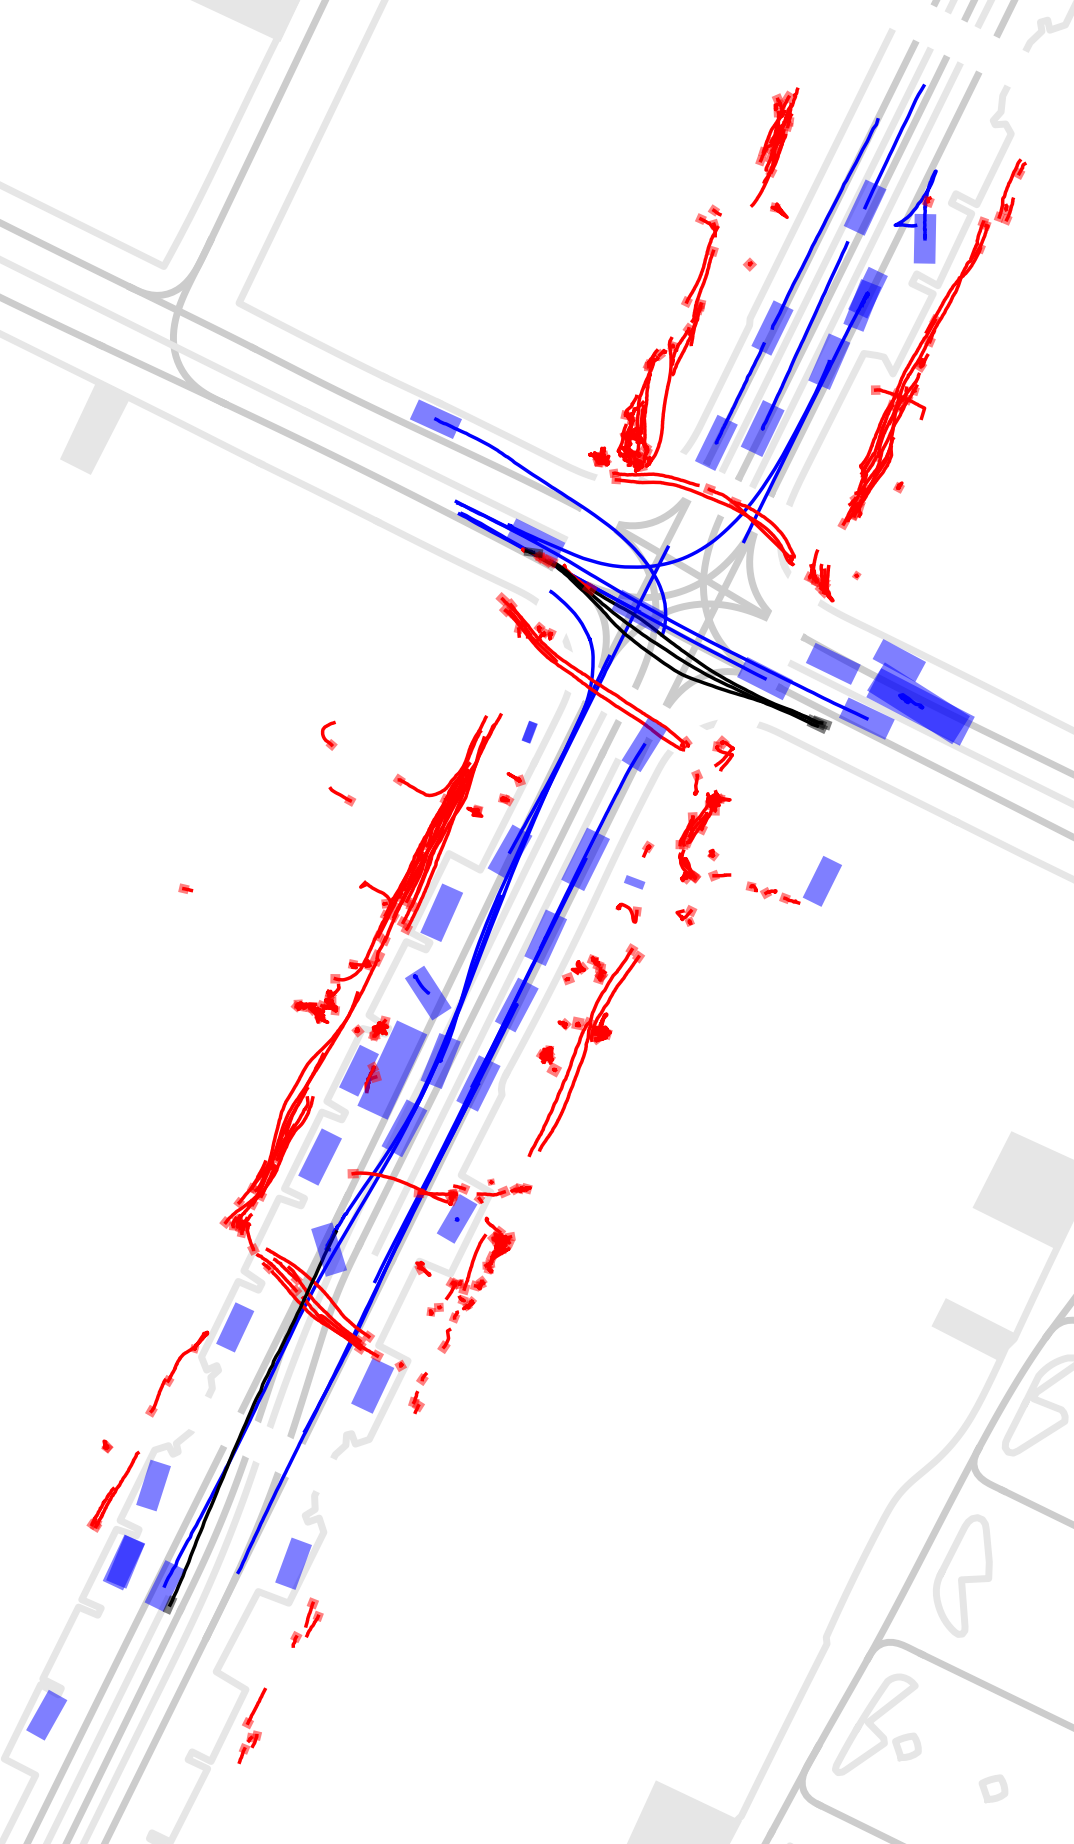

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from PIL import Image

def crop_axes_region(ax, xmin, xmax, ymin, ymax, pad_pixels=0, dpi=500):
    """
    从一个 matplotlib Axes 中裁剪指定数据区域，返回 PIL.Image。
    
    参数:
        ax: matplotlib.axes.Axes 对象
        xmin, xmax, ymin, ymax: 数据坐标范围
        pad_pixels: 裁剪时向内缩进像素，避免边线干扰
    
    返回:
        PIL.Image 对象
    """
    fig = ax.figure
    canvas = fig.canvas
    raw_dpi = ax.figure.dpi
    fig.set_dpi(dpi)   # 改变 Figure 的 DPI

    canvas.draw()  # 渲染 Figure
    argb = canvas.tostring_argb()
    w, h = canvas.get_width_height()

    # 坐标 -> 像素转换
    def data_to_pixel(xdata, ydata):
        px, py = ax.transData.transform(np.array([[xdata, ydata]]))[0]
        return int(round(px)), int(round(h - py))  # y 翻转
    
    pxmin, pymin = data_to_pixel(xmin, ymin)
    pxmax, pymax = data_to_pixel(xmax, ymax)

    fig.set_dpi(raw_dpi)  # 恢复原始 DPI

    # Figure 渲染成 RGBA 数组
    buf = np.frombuffer(argb, dtype=np.uint8)
    buf = buf.reshape(h, w, 4)
    buf = buf[:, :, [1, 2, 3, 0]]  # ARGB -> RGBA
    
    # 裁剪区域，加入 pad
    x0, x1 = sorted([pxmin, pxmax])
    y0, y1 = sorted([pymin, pymax])
    
    x0 += pad_pixels
    x1 -= pad_pixels
    y0 += pad_pixels
    y1 -= pad_pixels
    
    cropped = buf[y0:y1, x0:x1]
    return Image.fromarray(cropped)


def get_img(scenario, df, draw_traj=False):
    # LaneCenter lane = 3;
    # RoadLine road_line = 4;
    # RoadEdge road_edge = 5;
    # StopSign stop_sign = 7;
    # Crosswalk crosswalk = 8;
    # SpeedBump speed_bump = 9;
    # Driveway driveway = 10;
    items = {
        'lane': [],
        'road_line': [],
        'road_edge': [],
        'crosswalk': [],
        'driveway': [],
    }
    for item in scenario.map_features:
        if item.HasField('road_edge'):
            road_edge = [(i.x, i.y) for i in item.road_edge.polyline]
            items['road_edge'].append(road_edge)
        elif item.HasField('crosswalk'):
            crosswalk = [(i.x, i.y) for i in item.crosswalk.polygon]
            crosswalk.append(crosswalk[0])  # 闭合
            items['crosswalk'].append(crosswalk)
        elif item.HasField('driveway'):
            driveway = [(i.x, i.y) for i in item.driveway.polygon]
            driveway.append(driveway[0])  # 闭合
            items['driveway'].append(driveway)
        elif item.HasField('lane'):
            lane = [(i.x, i.y) for i in item.lane.polyline]
            items['lane'].append(lane)
        elif item.HasField('road_line'):
            road_line = [(i.x, i.y) for i in item.road_line.polyline]
            items['road_line'].append(road_line)

    xmin, xmax = df['center_x'].min(), df['center_x'].max()
    ymin, ymax = df['center_y'].min(), df['center_y'].max()
    expand_ratio = 0.05
    xmin = xmin - (xmax - xmin) * expand_ratio
    xmax = xmax + (xmax - xmin) * expand_ratio
    ymin = ymin - (ymax - ymin) * expand_ratio
    ymax = ymax + (ymax - ymin) * expand_ratio

    fig, ax = plt.subplots(dpi=300)
    ax.axis('equal')
    ax.axis('off')
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # ax.set_facecolor((0.9, 0.9, 0.9))
    # ax.add_patch(
    #     Polygon(np.array([[xmin, ymin], [xmax, ymin], [xmax, ymax], [xmin, ymax], [xmin, ymin]]),
    #     facecolor=(0.95, 0.95, 0.95), edgecolor=None, linewidth=1, zorder=0)
    # )
    for lane in items['lane']:
        ax.plot(*np.array(lane).T, color=(0.8, 0.8, 0.8), linewidth=1, zorder=100)
    for road_line in items['road_line']:
        ax.plot(*np.array(road_line).T, color=(0.9, 0.9, 0.9), linewidth=1, zorder=100)
    for driveway in items['driveway']:
        ax.add_patch(Polygon(np.array(driveway), facecolor=(0.9, 0.9, 0.9), edgecolor=None, zorder=100))
    for road_edge in items['road_edge']:
        ax.plot(*np.array(road_edge).T, color=(0.9, 0.9, 0.9), linewidth=1, zorder=100)
    for crosswalk in items['crosswalk']:
        ax.add_patch(Polygon(np.array(crosswalk), facecolor=(1.0, 1.0, 1.0), edgecolor=None, zorder=100))
    img0 = crop_axes_region(ax, xmin, xmax, ymin, ymax, pad_pixels=2, dpi=500)

    if draw_traj:
        for pid, group in df.groupby('id'):
            assert group['type'].nunique() == 1
            if group['type'].iloc[0] == 'VEHICLE':
                color = 'blue'
            elif group['type'].iloc[0] == 'PEDESTRIAN':
                color = 'red'
            else:
                color = 'black'
            plt.plot(group['center_x'], group['center_y'], color=color, lw=0.5, zorder=999)

            data = group.iloc[-1]
            x = data['center_x']
            y = data['center_y']
            width = data['width']
            length = data['length']
            heading = np.degrees(data['heading'])
            polygon = Polygon(np.array([
                [-length/2, -width/2],
                [ length/2, -width/2],
                [ length/2,  width/2],
                [-length/2,  width/2],
                [-length/2, -width/2],
            ]), 
                facecolor=color, edgecolor=None, alpha=0.5,
                transform=plt.matplotlib.transforms.Affine2D().rotate_deg_around(0, 0, heading).translate(x, y) + ax.transData,
                zorder=1000,
            )
            ax.add_patch(polygon)
        img1 = crop_axes_region(ax, xmin, xmax, ymin, ymax, pad_pixels=2, dpi=500)
    else:
        img1 = None

    plt.close(fig)
    return img0, img1, xmin, xmax, ymin, ymax

img0, img1, xmin, xmax, ymin, ymax = get_img(scenario, df, draw_traj=True)
print(xmin, xmax, ymin, ymax)
display(img0)
display(img1)